# Predicting the delivery time for food using Machine Learning

## 1. Problem definition

> How well can we predict the delivery time for food given data regarding previous deliveries

## 2. Data

> * delivery_train.csv - training dataset
> * delivery_validation.csv - validation data set
> * delivery_test.csv - testing data set
  
## 3. Evaluation

> The evaluation metric for this project is MAE, RMSE, and R² between the actual and predicted food delivery times.
> These metrics shall be tried out on several models such as RandomForest, Linear Regression, Ridge, HGBoost, XGBoost, CatBoost and LightGBM

**Note:** - the goal for the most regression evaluation metrics is to minimize the error.

## 4. Visual Representation of Results
> The results shall be represented as plots for easier overview of the metrics and feature importances.

In [1]:
# Import necessary modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

In [2]:
# Import train, validation and test sets
df_train = pd.read_csv("data/delivery_train.csv", low_memory=False)
df_val = pd.read_csv("data/delivery_validation.csv", low_memory=False)
df_test = pd.read_csv("data/delivery_test.csv", low_memory=False)

In [3]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 16 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   order_id                   500000 non-null  str    
 1   order_date                 500000 non-null  str    
 2   order_hour                 500000 non-null  int64  
 3   distance_km                489771 non-null  float64
 4   item_count                 492602 non-null  float64
 5   order_subtotal             487503 non-null  float64
 6   restaurant_prep_minutes    480090 non-null  float64
 7   courier_experience_months  472509 non-null  float64
 8   traffic_index              482123 non-null  float64
 9   temperature_c              485146 non-null  float64
 10  customer_rating            477506 non-null  float64
 11  vehicle_type               491085 non-null  str    
 12  weather                    488984 non-null  str    
 13  city_zone                  491987 non-nu

In [4]:
df_val.info()

<class 'pandas.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   order_id                   75000 non-null  str    
 1   order_date                 75000 non-null  str    
 2   order_hour                 75000 non-null  int64  
 3   distance_km                73457 non-null  float64
 4   item_count                 73862 non-null  float64
 5   order_subtotal             73118 non-null  float64
 6   restaurant_prep_minutes    72027 non-null  float64
 7   courier_experience_months  70794 non-null  float64
 8   traffic_index              72375 non-null  float64
 9   temperature_c              72743 non-null  float64
 10  customer_rating            71691 non-null  float64
 11  vehicle_type               73617 non-null  str    
 12  weather                    73403 non-null  str    
 13  city_zone                  73781 non-null  str    
 14  o

In [5]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   order_id                   75000 non-null  str    
 1   order_date                 75000 non-null  str    
 2   order_hour                 75000 non-null  int64  
 3   distance_km                73490 non-null  float64
 4   item_count                 73912 non-null  float64
 5   order_subtotal             73138 non-null  float64
 6   restaurant_prep_minutes    71921 non-null  float64
 7   courier_experience_months  70912 non-null  float64
 8   traffic_index              72334 non-null  float64
 9   temperature_c              72747 non-null  float64
 10  customer_rating            71585 non-null  float64
 11  vehicle_type               73671 non-null  str    
 12  weather                    73421 non-null  str    
 13  city_zone                  73742 non-null  str    
 14  o

In [6]:
df_train.head()

,order_id,order_date,order_hour,distance_km,item_count,order_subtotal,restaurant_prep_minutes,courier_experience_months,traffic_index,temperature_c,customer_rating,vehicle_type,weather,city_zone,order_channel,delivery_minutes
0,ORD-4101-0000001,2022-07-21,13,8.57,6.0,103.39,16.61,31.1,72.69,19.2,3.90,motorcycle,cloudy,suburban,mobile_app,48.51
1,ORD-4101-0000002,2023-11-22,20,5.74,6.0,62.87,25.32,25.4,38.53,0.2,4.85,scooter,cloudy,suburban,phone,66.37
2,ORD-4101-0000003,2025-05-21,12,8.11,4.0,25.90,18.68,18.0,62.29,23.2,4.44,scooter,clear,suburban,mobile_app,46.93
3,ORD-4101-0000004,2023-10-22,15,14.28,2.0,13.06,10.32,27.9,17.69,2.0,4.68,bicycle,cloudy,industrial,mobile_app,82.87
4,ORD-4101-0000005,2022-09-14,19,8.35,3.0,54.56,25.32,8.4,70.99,13.3,4.52,motorcycle,rain,central,mobile_app,71.17


# Preprocessing

In [7]:
# Make a copy of train dataset for preprocessing
df_train_temp = df_train.copy()
df_train_temp.info()

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 16 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   order_id                   500000 non-null  str    
 1   order_date                 500000 non-null  str    
 2   order_hour                 500000 non-null  int64  
 3   distance_km                489771 non-null  float64
 4   item_count                 492602 non-null  float64
 5   order_subtotal             487503 non-null  float64
 6   restaurant_prep_minutes    480090 non-null  float64
 7   courier_experience_months  472509 non-null  float64
 8   traffic_index              482123 non-null  float64
 9   temperature_c              485146 non-null  float64
 10  customer_rating            477506 non-null  float64
 11  vehicle_type               491085 non-null  str    
 12  weather                    488984 non-null  str    
 13  city_zone                  491987 non-nu

In [8]:
# Sort dataframe in order
df_train_temp.sort_values(by=["order_date"], inplace=True, ascending=True)

In [9]:
df_train_temp.head()

,order_id,order_date,order_hour,distance_km,item_count,order_subtotal,restaurant_prep_minutes,courier_experience_months,traffic_index,temperature_c,customer_rating,vehicle_type,weather,city_zone,order_channel,delivery_minutes
198100,ORD-4101-0198101,2022-01-01,18,5.03,6.0,93.31,16.19,32.6,26.05,16.1,NaN,scooter,cloudy,university,mobile_app,43.68
294867,ORD-4101-0294868,2022-01-01,17,4.21,7.0,48.82,22.00,10.7,49.34,31.1,3.88,NaN,clear,residential,mobile_app,47.49
249686,ORD-4101-0249687,2022-01-01,22,29.90,3.0,24.58,19.66,71.8,64.70,5.6,4.20,motorcycle,rain,university,mobile_app,105.25
212668,ORD-4101-0212669,2022-01-01,14,5.69,5.0,50.02,19.48,33.6,63.59,24.3,3.88,motorcycle,clear,residential,mobile_app,39.20
76509,ORD-4101-0076510,2022-01-01,0,2.17,3.0,36.57,10.47,17.7,28.99,16.8,4.38,bicycle,cloudy,suburban,website,29.33


In [10]:
# Convert order_date from str to datetime and extract detailed date time features

def process_datetime(df):
    """
    Convert the column "order_date" from type str to datetime
    and extract detailed datetime features
    """
    df["order_date"] = pd.to_datetime(df["order_date"], format=("%Y-%m-%d"))
    
    df["saleYear"] = df.order_date.dt.year
    df["saleMonth"] = df.order_date.dt.month
    df["saleDay"] = df.order_date.dt.day
    df["saleDayOfWeek"] = df.order_date.dt.day_of_week
    df["saleDayOfYear"] = df.order_date.dt.day_of_year
    
    print(f"Extracted saleYear, saleMonth, saleDay, saleDayOfWeek and saleDayOfYear")
    
    df.drop("order_date", axis=1, inplace=True)
    print(f"Dropped column order_date.")
    

In [11]:
process_datetime(df_train_temp)

Extracted saleYear, saleMonth, saleDay, saleDayOfWeek and saleDayOfYear
Dropped column order_date.


In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Identify categorical features
cat_features = ["vehicle_type", "weather", "city_zone", "order_channel"]

# Identify numerical features
num_features = ['order_hour', 'distance_km', 'item_count', 'order_subtotal',
                'restaurant_prep_minutes', 'courier_experience_months', 'traffic_index',
                'temperature_c', 'customer_rating',
                'saleYear', 'saleMonth', 'saleDay', 'saleDayOfWeek', 'saleDayOfYear']

# Preprocess categorical features
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Preprocess numerical categories
numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

# ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ("cat", categorical_transformer, cat_features),
    ("num", numerical_transformer, num_features)
])

In [13]:
df_train_temp.head()

,order_id,order_hour,distance_km,item_count,order_subtotal,restaurant_prep_minutes,courier_experience_months,traffic_index,temperature_c,customer_rating,vehicle_type,weather,city_zone,order_channel,delivery_minutes,saleYear,saleMonth,saleDay,saleDayOfWeek,saleDayOfYear
198100,ORD-4101-0198101,18,5.03,6.0,93.31,16.19,32.6,26.05,16.1,NaN,scooter,cloudy,university,mobile_app,43.68,2022,1,1,5,1
294867,ORD-4101-0294868,17,4.21,7.0,48.82,22.00,10.7,49.34,31.1,3.88,NaN,clear,residential,mobile_app,47.49,2022,1,1,5,1
249686,ORD-4101-0249687,22,29.90,3.0,24.58,19.66,71.8,64.70,5.6,4.20,motorcycle,rain,university,mobile_app,105.25,2022,1,1,5,1
212668,ORD-4101-0212669,14,5.69,5.0,50.02,19.48,33.6,63.59,24.3,3.88,motorcycle,clear,residential,mobile_app,39.20,2022,1,1,5,1
76509,ORD-4101-0076510,0,2.17,3.0,36.57,10.47,17.7,28.99,16.8,4.38,bicycle,cloudy,suburban,website,29.33,2022,1,1,5,1


In [14]:
df_train_temp.info()

<class 'pandas.DataFrame'>
Index: 500000 entries, 198100 to 209693
Data columns (total 20 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   order_id                   500000 non-null  str    
 1   order_hour                 500000 non-null  int64  
 2   distance_km                489771 non-null  float64
 3   item_count                 492602 non-null  float64
 4   order_subtotal             487503 non-null  float64
 5   restaurant_prep_minutes    480090 non-null  float64
 6   courier_experience_months  472509 non-null  float64
 7   traffic_index              482123 non-null  float64
 8   temperature_c              485146 non-null  float64
 9   customer_rating            477506 non-null  float64
 10  vehicle_type               491085 non-null  str    
 11  weather                    488984 non-null  str    
 12  city_zone                  491987 non-null  str    
 13  order_channel              493902 non-nu

## Full pipeline: preprocessing and model

In [15]:
%%time
from sklearn.ensemble import RandomForestRegressor

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("estimator", RandomForestRegressor(n_jobs=1,
                                       random_state=42))
])

CPU times: user 39.5 ms, sys: 8.18 ms, total: 47.7 ms
Wall time: 57.5 ms


In [16]:
%%time

### Fit the model on training data
X_train, y_train = df_train_temp.drop("delivery_minutes", axis=1), df_train_temp["delivery_minutes"]

model.fit(X_train, y_train)

CPU times: user 5min 12s, sys: 1.65 s, total: 5min 13s
Wall time: 5min 14s


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('estimator', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['order_id','order_hour','distance_km',...,'saleDay','saleDayOfWeek', 'saleDayOfYear']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. Thi

In [17]:
rf_model = model

In [18]:
# Process df_val and df_test for datetime
process_datetime(df_val)
process_datetime(df_test)

Extracted saleYear, saleMonth, saleDay, saleDayOfWeek and saleDayOfYear
Dropped column order_date.
Extracted saleYear, saleMonth, saleDay, saleDayOfWeek and saleDayOfYear
Dropped column order_date.


In [19]:
df_val.info()

<class 'pandas.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   order_id                   75000 non-null  str    
 1   order_hour                 75000 non-null  int64  
 2   distance_km                73457 non-null  float64
 3   item_count                 73862 non-null  float64
 4   order_subtotal             73118 non-null  float64
 5   restaurant_prep_minutes    72027 non-null  float64
 6   courier_experience_months  70794 non-null  float64
 7   traffic_index              72375 non-null  float64
 8   temperature_c              72743 non-null  float64
 9   customer_rating            71691 non-null  float64
 10  vehicle_type               73617 non-null  str    
 11  weather                    73403 non-null  str    
 12  city_zone                  73781 non-null  str    
 13  order_channel              74081 non-null  str    
 14  d

## Make predictions on validation and test sets

In [20]:
X_val, y_val = df_val.drop("delivery_minutes", axis=1), df_val["delivery_minutes"]
X_test, y_test = df_test.drop("delivery_minutes", axis=1), df_test["delivery_minutes"]

val_preds = model.predict(X_val)
test_preds = model.predict(X_test)

print("Val accuracy:", model.score(X_val, y_val))
print("Test accuracy:", model.score(X_test, y_test))

Val accuracy: 0.9199129867461746
Test accuracy: 0.9224596170244345


In [21]:
val_preds

array([62.3575, 50.7   , 44.3095, ..., 65.4948, 45.9237, 55.3555],
      shape=(75000,))

In [22]:
test_preds

array([35.8141, 49.1015, 58.534 , ..., 60.6373, 63.6598, 80.1408],
      shape=(75000,))

## Evaluation

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

# Create a function to evaluate the model on a few metrics

def show_scores(model, X, y, set_name=""):
    preds = model.predict(X)
    mae = mean_absolute_error(y, preds)
    mse = mean_squared_error(y, preds)
    rmse = root_mean_squared_error(y, preds)
    r2 = r2_score(y, preds)

    print(f"{set_name}:")
    print(f"MAE:  {mae:.3f}")
    print(f"MSE:  {mse:.3f}")
    print(f"RMSE:  {rmse:.3f}")
    print(f"R2-Score:  {r2:.3f}")

    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2-Score": r2}

In [24]:
show_scores(model, X_train, y_train, "Training Set")
show_scores(model, X_val, y_val, "Validation Set")
show_scores(model, X_test, y_test, "Test Set")

Training Set:
MAE:  1.746
MSE:  5.669
RMSE:  2.381
R2-Score:  0.989
Validation Set:
MAE:  4.705
MSE:  40.989
RMSE:  6.402
R2-Score:  0.920
Test Set:
MAE:  4.661
MSE:  39.644
RMSE:  6.296
R2-Score:  0.922


{'MAE': 4.660539177333334,
 'MSE': 39.644400246354266,
 'RMSE': 6.2963799318619795,
 'R2-Score': 0.9224596170244345}

### Hyperparameter tuning with `RandomizedSearchCV`

In [25]:
%%time
from sklearn.model_selection import RandomizedSearchCV

param_grid = {"estimator__n_estimators": np.arange(50, 150, 25),
             "estimator__max_depth": [10, 15, 20],
             "estimator__min_samples_split": np.arange(5, 20, 2),
             "estimator__min_samples_leaf": np.arange(5, 15, 2),
             "estimator__max_features": [0.5, 1, "sqrt"]}

# Instantiate RandomizedSearchCV model
rs_search_model = RandomizedSearchCV(estimator=model,
                                    param_distributions=param_grid,
                                    n_iter=20,
                                    cv=3,
                                    verbose=3,
                                    n_jobs=1,
                                    pre_dispatch="n_jobs",
                                    error_score='raise')
# Fit the RSCV model
print(f"Fitting started.")
rs_search_model.fit(X_train, y_train)
print(f"Fitting done.")
print("Best params:", rs_search_model.best_params_)

# Best pipeline
best_model = rs_search_model.best_estimator_

Fitting started.
Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV 1/3] END estimator__max_depth=10, estimator__max_features=sqrt, estimator__min_samples_leaf=5, estimator__min_samples_split=15, estimator__n_estimators=100;, score=0.752 total time=  18.7s
[CV 2/3] END estimator__max_depth=10, estimator__max_features=sqrt, estimator__min_samples_leaf=5, estimator__min_samples_split=15, estimator__n_estimators=100;, score=0.751 total time=  18.5s
[CV 3/3] END estimator__max_depth=10, estimator__max_features=sqrt, estimator__min_samples_leaf=5, estimator__min_samples_split=15, estimator__n_estimators=100;, score=0.759 total time=  18.5s
[CV 1/3] END estimator__max_depth=15, estimator__max_features=0.5, estimator__min_samples_leaf=5, estimator__min_samples_split=9, estimator__n_estimators=75;, score=0.918 total time=  56.6s
[CV 2/3] END estimator__max_depth=15, estimator__max_features=0.5, estimator__min_samples_leaf=5, estimator__min_samples_split=9, estimator__n_estimators

In [26]:
rs_search_model.best_params_

{'estimator__n_estimators': np.int64(125),
 'estimator__min_samples_split': np.int64(13),
 'estimator__min_samples_leaf': np.int64(7),
 'estimator__max_features': 0.5,
 'estimator__max_depth': 20}

In [27]:
best_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('estimator', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['order_id','order_hour','distance_km',...,'saleDay','saleDayOfWeek', 'saleDayOfYear']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. Thi

In [28]:
# Evaluate the best model
show_scores(best_model, X_train, y_train, set_name="Training Set")
show_scores(best_model, X_val, y_val, set_name="Validation Set")
show_scores(best_model, X_test, y_test, set_name="Test Set")

Training Set:
MAE:  3.504
MSE:  23.380
RMSE:  4.835
R2-Score:  0.954
Validation Set:
MAE:  4.678
MSE:  40.252
RMSE:  6.344
R2-Score:  0.921
Test Set:
MAE:  4.646
MSE:  39.197
RMSE:  6.261
R2-Score:  0.923


{'MAE': 4.646389212323432,
 'MSE': 39.197282178414625,
 'RMSE': 6.260773289172403,
 'R2-Score': 0.9233341341317155}

In [29]:
best_model.get_params

<bound method Pipeline.get_params of Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['vehicle_type', 'weather',
                                                   'city_zone',
                                                   'order_channel']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                      

In [30]:
best_rf_model = best_model

## Try out a few other models such as LinearRegression, Ridge, HistGradientBoostingRegressor, XGBRegressor, LGBMRegressor, and CatBoost and compare them to RandomForestRegressor 

### Linear Regression and Ridge

In [31]:
from sklearn.linear_model import LinearRegression, Ridge

lr_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("estimator", LinearRegression())
])

ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("estimator", Ridge(alpha=1.0, random_state=42))
])

In [32]:
%%time
# Fit LinearRegression
print(f"Fitting LinearRegression...")
lr_model.fit(X_train, y_train)

Fitting LinearRegression...
CPU times: user 1.54 s, sys: 365 ms, total: 1.9 s
Wall time: 652 ms


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('estimator', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['order_id','order_hour','distance_km',...,'saleDay','saleDayOfWeek', 'saleDayOfYear']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. Thi

In [33]:
%%time
# Fit Ridge
print(f"Fitting Ridge...")
ridge_model.fit(X_train, y_train)

Fitting Ridge...
CPU times: user 971 ms, sys: 503 ms, total: 1.47 s
Wall time: 451 ms


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('estimator', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['order_id','order_hour','distance_km',...,'saleDay','saleDayOfWeek', 'saleDayOfYear']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. Thi

In [34]:
# Evaluate the Linear models
print(f"Evaluation LinearRegression:")
show_scores(lr_model, X_train, y_train, set_name="Training Set")
show_scores(lr_model, X_val, y_val, set_name="Validation Set")
show_scores(lr_model, X_test, y_test, set_name="Test Set")

print(f"Evaluation Ridge:")
show_scores(ridge_model, X_train, y_train, set_name="Training Set")
show_scores(ridge_model, X_val, y_val, set_name="Validation Set")
show_scores(ridge_model, X_test, y_test, set_name="Test Set")

Evaluation LinearRegression:
Training Set:
MAE:  6.181
MSE:  70.176
RMSE:  8.377
R2-Score:  0.863
Validation Set:
MAE:  6.210
MSE:  70.572
RMSE:  8.401
R2-Score:  0.862
Test Set:
MAE:  6.139
MSE:  68.578
RMSE:  8.281
R2-Score:  0.866
Evaluation Ridge:
Training Set:
MAE:  6.181
MSE:  70.176
RMSE:  8.377
R2-Score:  0.863
Validation Set:
MAE:  6.210
MSE:  70.572
RMSE:  8.401
R2-Score:  0.862
Test Set:
MAE:  6.139
MSE:  68.578
RMSE:  8.281
R2-Score:  0.866


{'MAE': 6.139051944347943,
 'MSE': 68.57791885259927,
 'RMSE': 8.281178590792452,
 'R2-Score': 0.8658686205755677}

In [35]:
%%time
# Tune hyperparameters of the Ridge model
from sklearn.linear_model import RidgeCV

ridge_cv_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("estimator", RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5))
])

ridge_cv_model.fit(X_train, y_train)

CPU times: user 1min 57s, sys: 2min, total: 3min 58s
Wall time: 25.3 s


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('estimator', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['order_id','order_hour','distance_km',...,'saleDay','saleDayOfWeek', 'saleDayOfYear']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. Thi

In [36]:
ridge_cv_model.named_steps["estimator"].alpha_

np.float64(44.98432668969444)

In [37]:
print(f"Evaluation RidgeCV:")
show_scores(ridge_cv_model, X_train, y_train, set_name="Training Set")
show_scores(ridge_cv_model, X_val, y_val, set_name="Validation Set")
show_scores(ridge_cv_model, X_test, y_test, set_name="Test Set")

Evaluation RidgeCV:
Training Set:
MAE:  6.181
MSE:  70.176
RMSE:  8.377
R2-Score:  0.863
Validation Set:
MAE:  6.210
MSE:  70.571
RMSE:  8.401
R2-Score:  0.862
Test Set:
MAE:  6.139
MSE:  68.578
RMSE:  8.281
R2-Score:  0.866


{'MAE': 6.1387456784962025,
 'MSE': 68.57780389981622,
 'RMSE': 8.281171650184303,
 'R2-Score': 0.8658688454114276}

In [38]:
best_ridge_model = ridge_cv_model

### HistGradientBoostingRegressor

In [39]:
%%time
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import OrdinalEncoder

# Preprocessing without OneHotEncoder
preprocessor_hgb = ColumnTransformer(transformers=[
    ("num", SimpleImputer(strategy="mean"), num_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="constant")),
        ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
    ]), cat_features)
], remainder="drop")

cat_indices = list(range(len(num_features), len(num_features) + len(cat_features)))

print(cat_indices)

hgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor_hgb),
    ("estimator", HistGradientBoostingRegressor(
        categorical_features=cat_indices,
        random_state=42
    ))
])

hgb_model.fit(X_train, y_train)

[14, 15, 16, 17]
CPU times: user 5.63 s, sys: 5.79 s, total: 11.4 s
Wall time: 3.15 s


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('estimator', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['order_id','order_hour','distance_km',...,'saleDay','saleDayOfWeek', 'saleDayOfYear']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. Thi

In [40]:
print(f"Evaluation HistGradientBoostingRegressor:")
show_scores(hgb_model, X_train, y_train, set_name="Training Set")
show_scores(hgb_model, X_val, y_val, set_name="Validation Set")
show_scores(hgb_model, X_test, y_test, set_name="Test Set")

Evaluation HistGradientBoostingRegressor:
Training Set:
MAE:  4.301
MSE:  34.908
RMSE:  5.908
R2-Score:  0.932
Validation Set:
MAE:  4.344
MSE:  35.751
RMSE:  5.979
R2-Score:  0.930
Test Set:
MAE:  4.298
MSE:  34.706
RMSE:  5.891
R2-Score:  0.932


{'MAE': 4.297936998328016,
 'MSE': 34.70615454561032,
 'RMSE': 5.891192964553981,
 'R2-Score': 0.9321183194006506}

Hyperparameter tuning for HGB

In [41]:
%%time
param_grid_hgb = {
    "estimator__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "estimator__max_iter": [100, 200, 300],
    "estimator__max_leaf_nodes": [15, 31, 63],
    "estimator__max_depth": [None, 5, 10, 15],
    "estimator__min_samples_leaf": [10, 20, 30, 50],
    "estimator__l2_regularization": [0, 0.1, 0.5, 1.0]
}

hgb_cv_model = RandomizedSearchCV(
    estimator=hgb_model,
    param_distributions=param_grid_hgb,
    n_iter=20,
    cv=3,
    verbose=3,
    n_jobs=4,
    scoring="r2",
    random_state=42
)

hgb_cv_model.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
CPU times: user 23.8 s, sys: 19.3 s, total: 43.1 s
Wall time: 2min 29s


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'estimator__l2_regularization': [0, 0.1, ...], 'estimator__learning_rate': [0.01, 0.05, ...], 'estimator__max_depth': [None, 5, ...], 'estimator__max_iter': [100, 200, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",4
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",3
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, `

In [42]:
print(f"Evaluation Tuned HistGradientBoostingRegressor:")
show_scores(hgb_cv_model, X_train, y_train, set_name="Training Set")
show_scores(hgb_cv_model, X_val, y_val, set_name="Validation Set")
show_scores(hgb_cv_model, X_test, y_test, set_name="Test Set")

Evaluation Tuned HistGradientBoostingRegressor:
Training Set:
MAE:  4.237
MSE:  33.532
RMSE:  5.791
R2-Score:  0.935
Validation Set:
MAE:  4.317
MSE:  35.423
RMSE:  5.952
R2-Score:  0.931
Test Set:
MAE:  4.275
MSE:  34.320
RMSE:  5.858
R2-Score:  0.933


{'MAE': 4.274761056444135,
 'MSE': 34.31966381254771,
 'RMSE': 5.858298713154503,
 'R2-Score': 0.9328742556557573}

In [43]:
best_hgb_model = hgb_cv_model.best_estimator_

### XGBoost, LightGBM, CatBoost

In [44]:
pip install xgboost lightgbm catboost

Note: you may need to restart the kernel to use updated packages.


### XGBRegressor

In [45]:
%%time
from xgboost import XGBRegressor

xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("estimator", XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1
    ))
])

xgb_model.fit(X_train, y_train)

CPU times: user 12.7 s, sys: 1.29 s, total: 14 s
Wall time: 3.1 s


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('estimator', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['order_id','order_hour','distance_km',...,'saleDay','saleDayOfWeek', 'saleDayOfYear']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. Thi

In [46]:
print(f"Evaluation XGBRegressor:")
show_scores(xgb_model, X_train, y_train, set_name="Training Set")
show_scores(xgb_model, X_val, y_val, set_name="Validation Set")
show_scores(xgb_model, X_test, y_test, set_name="Test Set")

Evaluation XGBRegressor:
Training Set:
MAE:  4.192
MSE:  32.776
RMSE:  5.725
R2-Score:  0.936
Validation Set:
MAE:  4.321
MSE:  35.432
RMSE:  5.952
R2-Score:  0.931
Test Set:
MAE:  4.274
MSE:  34.311
RMSE:  5.858
R2-Score:  0.933


{'MAE': 4.274394888842774,
 'MSE': 34.31123251732129,
 'RMSE': 5.8575790662458225,
 'R2-Score': 0.9328907464049369}

Hyperparameter tuning for XGBRegressor

In [47]:
%%time
param_grid_xgb = {
    "estimator__n_estimators": [200, 400, 600],
    "estimator__learning_rate": [0.01, 0.05, 0.1],
    "estimator__max_depth": [4, 6, 8],
    "estimator__subsample": [0.7, 0.85, 1.0],
    "estimator__colsample_bytree": [0.7, 0.85, 1.0],
    "estimator__reg_lambda": [0.5, 1, 2, 5]
}

xgb_cv_model = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid_xgb,
    n_iter=30,
    cv=5,
    n_jobs=4,
    verbose=3,
    random_state=42,
)

xgb_cv_model.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
CPU times: user 41.5 s, sys: 6.24 s, total: 47.7 s
Wall time: 9min 36s


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'estimator__colsample_bytree': [0.7, 0.85, ...], 'estimator__learning_rate': [0.01, 0.05, ...], 'estimator__max_depth': [4, 6, ...], 'estimator__n_estimators': [200, 400, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",4
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",3
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimat

In [48]:
print(f"Evaluation Tuned XGBRegressor:")
show_scores(xgb_cv_model, X_train, y_train, set_name="Training Set")
show_scores(xgb_cv_model, X_val, y_val, set_name="Validation Set")
show_scores(xgb_cv_model, X_test, y_test, set_name="Test Set")

Evaluation Tuned XGBRegressor:
Training Set:
MAE:  4.210
MSE:  33.311
RMSE:  5.772
R2-Score:  0.935
Validation Set:
MAE:  4.309
MSE:  35.273
RMSE:  5.939
R2-Score:  0.931
Test Set:
MAE:  4.260
MSE:  34.138
RMSE:  5.843
R2-Score:  0.933


{'MAE': 4.260323586016846,
 'MSE': 34.13787440937652,
 'RMSE': 5.842762566575551,
 'R2-Score': 0.9332298170933172}

In [49]:
best_xgb_model = xgb_cv_model.best_estimator_

### LightGBM Regressor

In [50]:
%%time
from lightgbm import LGBMRegressor

# Instantiate a preprocessor without OneHotEncoder because LGBM requires integer-encoded cateogories
preprocessor_lgbm = ColumnTransformer(transformers=[
    ("num", Pipeline([("imputer", SimpleImputer(strategy="mean"))]), num_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
        ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
    ]), cat_features)
])

lgbm_model = Pipeline(steps=[
    ("preprocessor", preprocessor_lgbm),
    ("estimator", LGBMRegressor(
        n_estimators=300,
        random_state=42,
        categorical_features=list(range(len(cat_features)))
    ))
])

lgbm_model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003350 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1827
[LightGBM] [Info] Number of data points in the train set: 500000, number of used features: 18
[LightGBM] [Info] Start training from score 60.254248
CPU times: user 7.15 s, sys: 3.02 s, total: 10.2 s
Wall time: 2.99 s


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('estimator', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['order_id','order_hour','distance_km',...,'saleDay','saleDayOfWeek', 'saleDayOfYear']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. Thi

In [51]:
print(f"Evaluation LGBMRegressor:")
show_scores(lgbm_model, X_train, y_train, set_name="Training Set")
show_scores(lgbm_model, X_val, y_val, set_name="Validation Set")
show_scores(lgbm_model, X_test, y_test, set_name="Test Set")

Evaluation LGBMRegressor:
Training Set:
MAE:  4.237
MSE:  32.840
RMSE:  5.731
R2-Score:  0.936
Validation Set:
MAE:  4.372
MSE:  36.053
RMSE:  6.004
R2-Score:  0.930
Test Set:
MAE:  4.322
MSE:  34.817
RMSE:  5.901
R2-Score:  0.932


{'MAE': 4.3223792749913645,
 'MSE': 34.81695985970464,
 'RMSE': 5.90058978914012,
 'R2-Score': 0.9319015955648198}

Hyperparameter tuning for LGBMRegressor

In [52]:
%%time
param_grid_lgbm = {
    "estimator__n_estimators": [200, 400, 600],
    "estimator__learning_rate": [0.01, 0.05, 0.1],
    "estimator__num_leaves": [15, 31, 63, 127],
    "estimator__min_child_samples": [10, 20, 50],
    "estimator__subsample": [0.7, 0.85, 1.0]
}

lgbm_cv_model = RandomizedSearchCV(
    param_distributions=param_grid_lgbm,
    estimator=lgbm_model,
    n_iter=30,
    cv=5,
    n_jobs=4,
    random_state=42,
    verbose=3
)

lgbm_cv_model.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004119 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1827
[LightGBM] [Info] Number of data points in the train set: 500000, number of used features: 18
[LightGBM] [Info] Start training from score 60.254248
CPU times: user 35.3 s, sys: 8.13 s, total: 43.5 s
Wall time: 9min 39s


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'estimator__learning_rate': [0.01, 0.05, ...], 'estimator__min_child_samples': [10, 20, ...], 'estimator__n_estimators': [200, 400, ...], 'estimator__num_leaves': [15, 31, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",4
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",3
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimato

In [53]:
print(f"Evaluation tuned LGBMRegressor:")
show_scores(lgbm_cv_model, X_train, y_train, set_name="Training Set")
show_scores(lgbm_cv_model, X_val, y_val, set_name="Validation Set")
show_scores(lgbm_cv_model, X_test, y_test, set_name="Test Set")

Evaluation tuned LGBMRegressor:
Training Set:
MAE:  4.249
MSE:  33.439
RMSE:  5.783
R2-Score:  0.935
Validation Set:
MAE:  4.356
MSE:  35.855
RMSE:  5.988
R2-Score:  0.930
Test Set:
MAE:  4.306
MSE:  34.557
RMSE:  5.879
R2-Score:  0.932


{'MAE': 4.3062628946722175,
 'MSE': 34.55682344190137,
 'RMSE': 5.8785052047184045,
 'R2-Score': 0.9324103957317289}

In [54]:
best_lgbm_model = lgbm_cv_model.best_estimator_

### CatBoost

In [55]:
%%time
from catboost import CatBoostRegressor


# Drop order_id manually because CatBoost uses raw X data
X_train_cb = X_train.drop("order_id", axis=1)
X_val_cb = X_val.drop("order_id", axis=1)
X_test_cb = X_test.drop("order_id", axis=1)

# Only fill missing values, without encoding
for feature_name in cat_features:
    X_train_cb.fillna({feature_name: "missing"}, inplace=True)
    X_val_cb.fillna({feature_name: "missing"}, inplace=True)
    X_test_cb.fillna({feature_name: "missing"}, inplace=True)

for feature_name in num_features:
    X_train_cb.fillna({feature_name: X_train_cb[feature_name].mean()}, inplace=True)
    X_val_cb.fillna({feature_name: X_val_cb[feature_name].mean()}, inplace=True)
    X_test_cb.fillna({feature_name: X_test_cb[feature_name].mean()}, inplace=True)


CPU times: user 120 ms, sys: 32 ms, total: 152 ms
Wall time: 868 ms


In [56]:
X_train_cb.isna().sum()

order_hour                   0
distance_km                  0
item_count                   0
order_subtotal               0
restaurant_prep_minutes      0
courier_experience_months    0
traffic_index                0
temperature_c                0
customer_rating              0
vehicle_type                 0
weather                      0
city_zone                    0
order_channel                0
saleYear                     0
saleMonth                    0
saleDay                      0
saleDayOfWeek                0
saleDayOfYear                0
dtype: int64

In [57]:
%%time
# Fit the model
cat_feature_indices = [X_train_cb.columns.get_loc(c) for c in cat_features]

catboost_model = CatBoostRegressor(
    cat_features=cat_feature_indices,
    random_state=42,
    verbose=False
)

catboost_model.fit(X_train_cb, y_train)

CPU times: user 8min 39s, sys: 22.6 s, total: 9min 2s
Wall time: 1min 9s


CatBoostRegressor(cat_features=[9, 10, 11, 12], loss_function='RMSE', random_state=42, verbose=False)

In [58]:
print(f"Evaluation CatBoost:")
show_scores(catboost_model, X_train_cb, y_train, set_name="Training Set")
show_scores(catboost_model, X_val_cb, y_val, set_name="Validation Set")
show_scores(catboost_model, X_test_cb, y_test, set_name="Test Set")

Evaluation CatBoost:
Training Set:
MAE:  4.230
MSE:  33.527
RMSE:  5.790
R2-Score:  0.935
Validation Set:
MAE:  4.298
MSE:  35.192
RMSE:  5.932
R2-Score:  0.931
Test Set:
MAE:  4.248
MSE:  34.047
RMSE:  5.835
R2-Score:  0.933


{'MAE': 4.248362437952344,
 'MSE': 34.04714973079524,
 'RMSE': 5.834993550193114,
 'R2-Score': 0.9334072652645297}

Hyperparameter Tuning for CatBoost

In [59]:
%%time

catboost_model = CatBoostRegressor(
    cat_features=cat_feature_indices,
    random_state=42,
    verbose=False
)

param_grid_catboost = {
    "iterations": [300, 600, 1000],
    "learning_rate": [0.01, 0.05, 0.1],
    "depth": [4, 6, 8, 10],
    "l2_leaf_reg": [1, 3, 5, 10]
}

randomized_search_res = catboost_model.randomized_search(
    param_distributions=param_grid_catboost,
    X=X_train_cb,
    y=y_train,
    n_iter=30,
    cv=5,
    verbose=False
)

print(f"Best params: {randomized_search_res["params"]}")


bestTest = 5.894455941
bestIteration = 599


bestTest = 5.877111544
bestIteration = 986


bestTest = 6.167638556
bestIteration = 999


bestTest = 6.167050963
bestIteration = 999


bestTest = 5.879201957
bestIteration = 995


bestTest = 5.886994517
bestIteration = 299

[CV 3/3] END estimator__l2_regularization=0.1, estimator__learning_rate=0.05, estimator__max_depth=15, estimator__max_iter=300, estimator__max_leaf_nodes=63, estimator__min_samples_leaf=10;, score=0.931 total time=  11.2s
[CV 3/3] END estimator__l2_regularization=0.5, estimator__learning_rate=0.01, estimator__max_depth=15, estimator__max_iter=300, estimator__max_leaf_nodes=63, estimator__min_samples_leaf=30;, score=0.913 total time=  18.5s
[CV 1/3] END estimator__l2_regularization=1.0, estimator__learning_rate=0.2, estimator__max_depth=None, estimator__max_iter=100, estimator__max_leaf_nodes=63, estimator__min_samples_leaf=20;, score=0.930 total time=   4.3s
[CV 1/3] END estimator__l2_regularization=0, estimator__learnin

In [60]:
%%time
# Fit the CatBoost model with the best parameters 
best_catboost_model = CatBoostRegressor(
    cat_features=cat_feature_indices,
    learning_rate=0.05,
    l2_leaf_reg=3,
    iterations=1000,
    random_state=42,
    verbose=False)

best_catboost_model.fit(X_train_cb, y_train)

CPU times: user 8min 16s, sys: 9.61 s, total: 8min 25s
Wall time: 1min 1s


CatBoostRegressor(cat_features=[9, 10, 11, 12], iterations=1000, l2_leaf_reg=3, learning_rate=0.05, loss_function='RMSE', random_state=42, verbose=False)

In [61]:
print(f"Evaluation Best CatBoost:")
show_scores(best_catboost_model, X_train_cb, y_train, set_name="Training Set")
show_scores(best_catboost_model, X_val_cb, y_val, set_name="Validation Set")
show_scores(best_catboost_model, X_test_cb, y_test, set_name="Test Set")

Evaluation Best CatBoost:
Training Set:
MAE:  4.251
MSE:  34.096
RMSE:  5.839
R2-Score:  0.933
Validation Set:
MAE:  4.293
MSE:  35.103
RMSE:  5.925
R2-Score:  0.931
Test Set:
MAE:  4.246
MSE:  33.955
RMSE:  5.827
R2-Score:  0.934


{'MAE': 4.246055600399373,
 'MSE': 33.954752874598576,
 'RMSE': 5.82707069414801,
 'R2-Score': 0.9335879840437445}

### Summarize all results for graphical representation

In [62]:
# Linear Regression
res_linear_reg_train = show_scores(lr_model, X_train, y_train, "Training Set")
res_linear_reg_val = show_scores(lr_model, X_val, y_val, "Val Set")
res_linear_reg_test = show_scores(lr_model, X_test, y_test, "Test Set")

Training Set:
MAE:  6.181
MSE:  70.176
RMSE:  8.377
R2-Score:  0.863
Val Set:
MAE:  6.210
MSE:  70.572
RMSE:  8.401
R2-Score:  0.862
Test Set:
MAE:  6.139
MSE:  68.578
RMSE:  8.281
R2-Score:  0.866


In [63]:
# Ridge
res_ridge_train = show_scores(ridge_model, X_train, y_train, "Training Set")
res_ridge_val = show_scores(ridge_model, X_val, y_val, "Val Set")
res_ridge_test = show_scores(ridge_model, X_test, y_test, "Test Set")

Training Set:
MAE:  6.181
MSE:  70.176
RMSE:  8.377
R2-Score:  0.863
Val Set:
MAE:  6.210
MSE:  70.572
RMSE:  8.401
R2-Score:  0.862
Test Set:
MAE:  6.139
MSE:  68.578
RMSE:  8.281
R2-Score:  0.866


In [64]:
# Ridge Tuned
res_ridge_train_tuned = show_scores(best_ridge_model, X_train, y_train, "Training Set")
res_ridge_val_tuned = show_scores(best_ridge_model, X_val, y_val, "Val Set")
res_ridge_test_tuned = show_scores(best_ridge_model, X_test, y_test, "Test Set")

Training Set:
MAE:  6.181
MSE:  70.176
RMSE:  8.377
R2-Score:  0.863
Val Set:
MAE:  6.210
MSE:  70.571
RMSE:  8.401
R2-Score:  0.862
Test Set:
MAE:  6.139
MSE:  68.578
RMSE:  8.281
R2-Score:  0.866


In [65]:
# Random Forest Regressor
res_rf_train = show_scores(rf_model, X_train, y_train, "Training Set")
res_rf_val = show_scores(rf_model, X_val, y_val, "Val Set")
res_rf_test = show_scores(rf_model, X_test, y_test, "Test Set")

Training Set:
MAE:  1.746
MSE:  5.669
RMSE:  2.381
R2-Score:  0.989
Val Set:
MAE:  4.705
MSE:  40.989
RMSE:  6.402
R2-Score:  0.920
Test Set:
MAE:  4.661
MSE:  39.644
RMSE:  6.296
R2-Score:  0.922


In [66]:
# Random Forest Regressor Tuned
res_rf_train_tuned = show_scores(best_rf_model, X_train, y_train, "Training Set")
res_rf_val_tuned = show_scores(best_rf_model, X_val, y_val, "Val Set")
res_rf_test_tuned = show_scores(best_rf_model, X_test, y_test, "Test Set")

Training Set:
MAE:  3.504
MSE:  23.380
RMSE:  4.835
R2-Score:  0.954
Val Set:
MAE:  4.678
MSE:  40.252
RMSE:  6.344
R2-Score:  0.921
Test Set:
MAE:  4.646
MSE:  39.197
RMSE:  6.261
R2-Score:  0.923


In [67]:
# HistGradientBoosting
res_hgb_train = show_scores(hgb_model, X_train, y_train, "Training Set")
res_hgb_val = show_scores(hgb_model, X_val, y_val, "Val Set")
res_hgb_test = show_scores(hgb_model, X_test, y_test, "Test Set")

Training Set:
MAE:  4.301
MSE:  34.908
RMSE:  5.908
R2-Score:  0.932
Val Set:
MAE:  4.344
MSE:  35.751
RMSE:  5.979
R2-Score:  0.930
Test Set:
MAE:  4.298
MSE:  34.706
RMSE:  5.891
R2-Score:  0.932


In [68]:
# HistGradientBoosting
res_hgb_train_tuned = show_scores(best_hgb_model, X_train, y_train, "Training Set")
res_hgb_val_tuned = show_scores(best_hgb_model, X_val, y_val, "Val Set")
res_hgb_test_tuned = show_scores(best_hgb_model, X_test, y_test, "Test Set")

Training Set:
MAE:  4.237
MSE:  33.532
RMSE:  5.791
R2-Score:  0.935
Val Set:
MAE:  4.317
MSE:  35.423
RMSE:  5.952
R2-Score:  0.931
Test Set:
MAE:  4.275
MSE:  34.320
RMSE:  5.858
R2-Score:  0.933


In [69]:
# XGBoost
res_xgb_train = show_scores(xgb_model, X_train, y_train, "Training Set")
res_xgb_val = show_scores(xgb_model, X_val, y_val, "Val Set")
res_xgb_test = show_scores(xgb_model, X_test, y_test, "Test Set")

Training Set:
MAE:  4.192
MSE:  32.776
RMSE:  5.725
R2-Score:  0.936
Val Set:
MAE:  4.321
MSE:  35.432
RMSE:  5.952
R2-Score:  0.931
Test Set:
MAE:  4.274
MSE:  34.311
RMSE:  5.858
R2-Score:  0.933


In [70]:
# XGBoost Tuned
res_xgb_train_tuned = show_scores(best_xgb_model, X_train, y_train, "Training Set")
res_xgb_val_tuned = show_scores(best_xgb_model, X_val, y_val, "Val Set")
res_xgb_test_tuned = show_scores(best_xgb_model, X_test, y_test, "Test Set")

Training Set:
MAE:  4.210
MSE:  33.311
RMSE:  5.772
R2-Score:  0.935
Val Set:
MAE:  4.309
MSE:  35.273
RMSE:  5.939
R2-Score:  0.931
Test Set:
MAE:  4.260
MSE:  34.138
RMSE:  5.843
R2-Score:  0.933


In [71]:
# LightBGM
res_lbgm_train = show_scores(lgbm_model, X_train, y_train, "Training Set")
res_lbgm_val = show_scores(lgbm_model, X_val, y_val, "Val Set")
res_lbgm_test = show_scores(lgbm_model, X_test, y_test, "Test Set")

Training Set:
MAE:  4.237
MSE:  32.840
RMSE:  5.731
R2-Score:  0.936
Val Set:
MAE:  4.372
MSE:  36.053
RMSE:  6.004
R2-Score:  0.930
Test Set:
MAE:  4.322
MSE:  34.817
RMSE:  5.901
R2-Score:  0.932


In [72]:
# LightBGM Tuned
res_lbgm_train_tuned = show_scores(best_lgbm_model, X_train, y_train, "Training Set")
res_lbgm_val_tuned = show_scores(best_lgbm_model, X_val, y_val, "Val Set")
res_lbgm_test_tuned = show_scores(best_lgbm_model, X_test, y_test, "Test Set")

Training Set:
MAE:  4.249
MSE:  33.439
RMSE:  5.783
R2-Score:  0.935
Val Set:
MAE:  4.356
MSE:  35.855
RMSE:  5.988
R2-Score:  0.930
Test Set:
MAE:  4.306
MSE:  34.557
RMSE:  5.879
R2-Score:  0.932


In [73]:
# CatBoost
res_catboost_train = show_scores(catboost_model, X_train_cb, y_train, "Training Set")
res_catboost_val = show_scores(catboost_model, X_val_cb, y_val, "Val Set")
res_catboost_test = show_scores(catboost_model, X_test_cb, y_test, "Test Set")

Training Set:
MAE:  4.251
MSE:  34.096
RMSE:  5.839
R2-Score:  0.933
Val Set:
MAE:  4.293
MSE:  35.103
RMSE:  5.925
R2-Score:  0.931
Test Set:
MAE:  4.246
MSE:  33.955
RMSE:  5.827
R2-Score:  0.934


In [74]:
# CatBoost Tuned
res_catboost_train_tuned = show_scores(best_catboost_model, X_train_cb, y_train, "Training Set")
res_catboost_val_tuned = show_scores(best_catboost_model, X_val_cb, y_val, "Val Set")
res_catboost_test_tuned = show_scores(best_catboost_model, X_test_cb, y_test, "Test Set")

Training Set:
MAE:  4.251
MSE:  34.096
RMSE:  5.839
R2-Score:  0.933
Val Set:
MAE:  4.293
MSE:  35.103
RMSE:  5.925
R2-Score:  0.931
Test Set:
MAE:  4.246
MSE:  33.955
RMSE:  5.827
R2-Score:  0.934


# Project Summary
A single view summarizing every model tried including final performance ranking, impact of tuning, generalization gap, and tradeoff
between tuning and compute cost

In [75]:
final_results = {
    "Linear Regression": {"train_r2": res_linear_reg_train["R2-Score"], "val_r2": res_linear_reg_val["R2-Score"],
                          "test_r2": res_linear_reg_test["R2-Score"], "test_mae": res_linear_reg_test["MAE"], "tuned": False},
    "Ridge":             {"train_r2": res_ridge_train["R2-Score"], "val_r2": res_ridge_val["R2-Score"],
                          "test_r2": res_ridge_test["R2-Score"], "test_mae": res_ridge_test["MAE"], "tuned": False,
                         "tune_min": 0.4, "test_r2_tuned": res_ridge_test_tuned["R2-Score"], "test_mae_tuned": res_ridge_test_tuned["MAE"]},
    "Random Forest":     {"train_r2": res_rf_train["R2-Score"], "val_r2": res_rf_val["R2-Score"],
                          "test_r2": res_rf_test["R2-Score"], "test_mae": res_rf_test["MAE"], "tuned": True,
                         "tune_min": 27.9, "test_r2_tuned": res_rf_test_tuned["R2-Score"], "test_mae_tuned": res_rf_test_tuned["MAE"],
                         "train_r2_tuned": res_rf_train_tuned["R2-Score"]},
    "HistGradBoosting":  {"train_r2": res_hgb_train["R2-Score"], "val_r2": res_hgb_val["R2-Score"],
                          "test_r2": res_hgb_test["R2-Score"], "test_mae": res_hgb_test["MAE"], "tuned": True,
                         "tune_min": 1.8, "test_r2_tuned": res_hgb_test_tuned["R2-Score"], "test_mae_tuned": res_hgb_test_tuned["MAE"],
                         "train_r2_tuned": res_hgb_train_tuned["R2-Score"]},
    "XGBoost":          {"train_r2": res_xgb_train["R2-Score"], "val_r2": res_xgb_val["R2-Score"],
                          "test_r2": res_xgb_test["R2-Score"], "test_mae": res_xgb_test["MAE"], "tuned": True,
                         "tune_min": 7.8, "test_r2_tuned": res_xgb_test_tuned["R2-Score"], "test_mae_tuned": res_xgb_test_tuned["MAE"],
                         "train_r2_tuned": res_xgb_train_tuned["R2-Score"]},
    "LightBGM":          {"train_r2": res_lbgm_train["R2-Score"], "val_r2": res_lbgm_val["R2-Score"],
                          "test_r2": res_lbgm_test["R2-Score"], "test_mae": res_lbgm_test["MAE"], "tuned": True,
                         "tune_min": 9.1, "test_r2_tuned": res_lbgm_test_tuned["R2-Score"], "test_mae_tuned": res_lbgm_test_tuned["MAE"],
                         "train_r2_tuned": res_lbgm_train_tuned["R2-Score"]},
    "CatBoost":          {"train_r2": res_catboost_train["R2-Score"], "val_r2": res_catboost_val["R2-Score"],
                          "test_r2": res_catboost_test["R2-Score"], "test_mae": res_catboost_test["MAE"], "tuned": True,
                         "tune_min": 29.9, "test_r2_tuned": res_catboost_test_tuned["R2-Score"], "test_mae_tuned": res_catboost_test_tuned["MAE"],
                         "train_r2_tuned": res_catboost_train_tuned["R2-Score"]}
}

model_color_codes = {
    "Linear Regression": "#9CA3AF", "Ridge": "#6B7280",
    "Random Forest": "#16A34A", "HistGradBoosting": "#2563EB",
    "XGBoost": "#7C3AED", "LightBGM": "#DB2777", "CatBoost": "#EA580C"
}

### Figure 1: Final Test R2 (best variant)

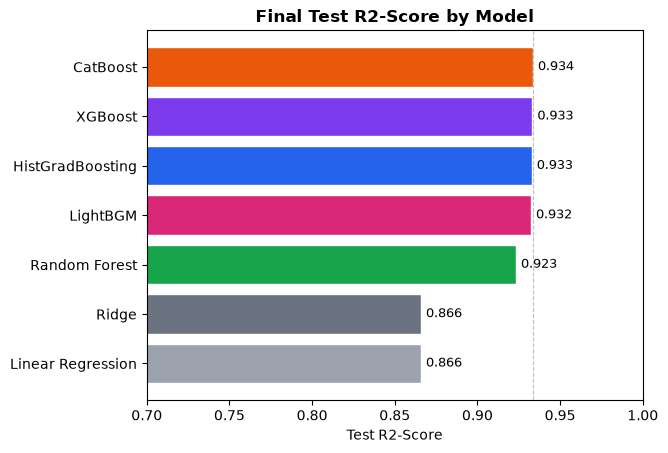

In [76]:
fig1, ax1 = plt.subplots()
model_names = list(final_results.keys())
final_r2 = [final_results[m].get("test_r2_tuned", final_results[m]["test_r2"]) for m in model_names]
order = np.argsort(final_r2)
model_names_sorted = [model_names[i] for i in order]
final_r2_sorted = [final_r2[i] for i in order]
model_colors_sorted = [model_color_codes[c] for c in model_names_sorted]

bars = ax1.barh(model_names_sorted, final_r2_sorted, color=model_colors_sorted, edgecolor="white")
ax1.set_xlim(0.7, 1.0)
ax1.set_xlabel("Test R2-Score")
ax1.set_title("Final Test R2-Score by Model", fontweight="bold")
for bar, val in zip(bars, final_r2_sorted):
    ax1.text(val + 0.003, bar.get_y() + bar.get_height()/2, f"{round(val, 3)}", va="center", fontsize=9)
ax1.axvline(final_r2_sorted[-1], color="gray", linestyle="--", linewidth=0.8, alpha=0.5)

plt.show()

  ### Figure 2: Untuned vs Tuned Test R2

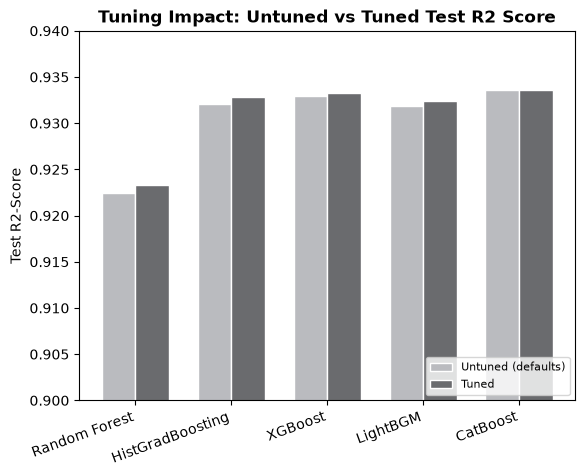

In [77]:
fig2, ax2 = plt.subplots()
tuned_models = [m for m in model_names if final_results[m]["tuned"]]
x_pos = np.arange(len(tuned_models))
width = 0.35
tuned_r2_vals = [final_results[i]["test_r2_tuned"] for i in tuned_models]
untuned_r2_vals = [final_results[i]["test_r2"] for i in tuned_models]

ax2.bar(x_pos - width/2, untuned_r2_vals, width, label="Untuned (defaults)", color="#babbbf", edgecolor="white")
ax2.bar(x_pos + width/2, tuned_r2_vals, width, label="Tuned", color="#6a6b6e", edgecolor="white")
ax2.set_xticks(x_pos)
ax2.set_xticklabels(tuned_models, rotation=20, ha="right")
ax2.set_ylim(0.90, 0.94)
ax2.set_ylabel("Test R2-Score")
ax2.set_title("Tuning Impact: Untuned vs Tuned Test R2 Score", fontweight="bold")
ax2.legend(fontsize=8, loc="lower right")

plt.show()

### Figure 3: Train vs Test R2 (overfitting gap)

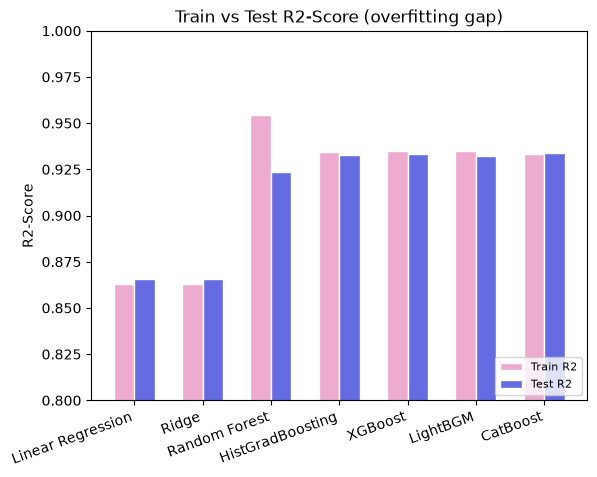

In [78]:
fig3, ax3 = plt.subplots()
r2_score_train = [final_results[m].get("train_r2_tuned", final_results[m]["train_r2"]) for m in model_names]
r2_score_test = [final_results[m].get("test_r2_tuned", final_results[m]["test_r2"]) for m in model_names]
x_pos = np.arange(len(model_names))
width = 0.3
ax3.bar(x_pos - width/2, r2_score_train, width, label="Train R2", color="#edabcf", edgecolor="white")
ax3.bar(x_pos + width/2, r2_score_test, width, label="Test R2", color="#656be0", edgecolor="white")
ax3.set_xticks(x_pos)
ax3.set_xticklabels(model_names, rotation=20, ha="right")
ax3.set_ylim(0.8, 1.0)
ax3.set_ylabel("R2-Score")
ax3.set_title("Train vs Test R2-Score (overfitting gap)")
ax3.legend(fontsize=8, loc="lower right")

plt.show()

### Figure 4: Tuning cost vs benefit

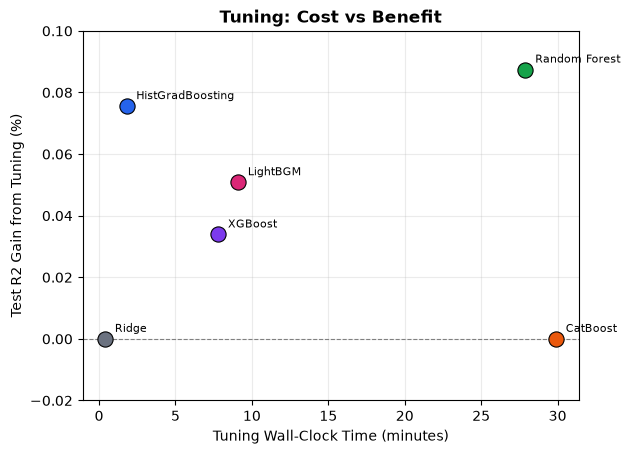

In [79]:

fig4, ax4 = plt.subplots()
cost_models = [m for m in model_names if "tune_min" in final_results[m]]
tune_times = [final_results[m]["tune_min"] for m in cost_models]
r2_gain = [(final_results[m]["test_r2_tuned"]-final_results[m]["test_r2"]) * 100 for m in cost_models]

for m, t, g in zip(cost_models, tune_times, r2_gain):
    ax4.scatter(t, g, s=120, color=model_color_codes[m], edgecolor="black", linewidth=0.8, zorder=3)
    ax4.annotate(m, (t, g), textcoords="offset points", xytext=(7, 5), fontsize=8)

ax4.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax4.set_xlabel("Tuning Wall-Clock Time (minutes)")
ax4.set_ylabel("Test R2 Gain from Tuning (%)")
ax4.set_ylim(-0.02, 0.1)
ax4.set_title("Tuning: Cost vs Benefit", fontweight="bold")
ax4.grid(alpha=0.25)

plt.show()

### Figure 5: Actual vs Predicted Scatter Grid

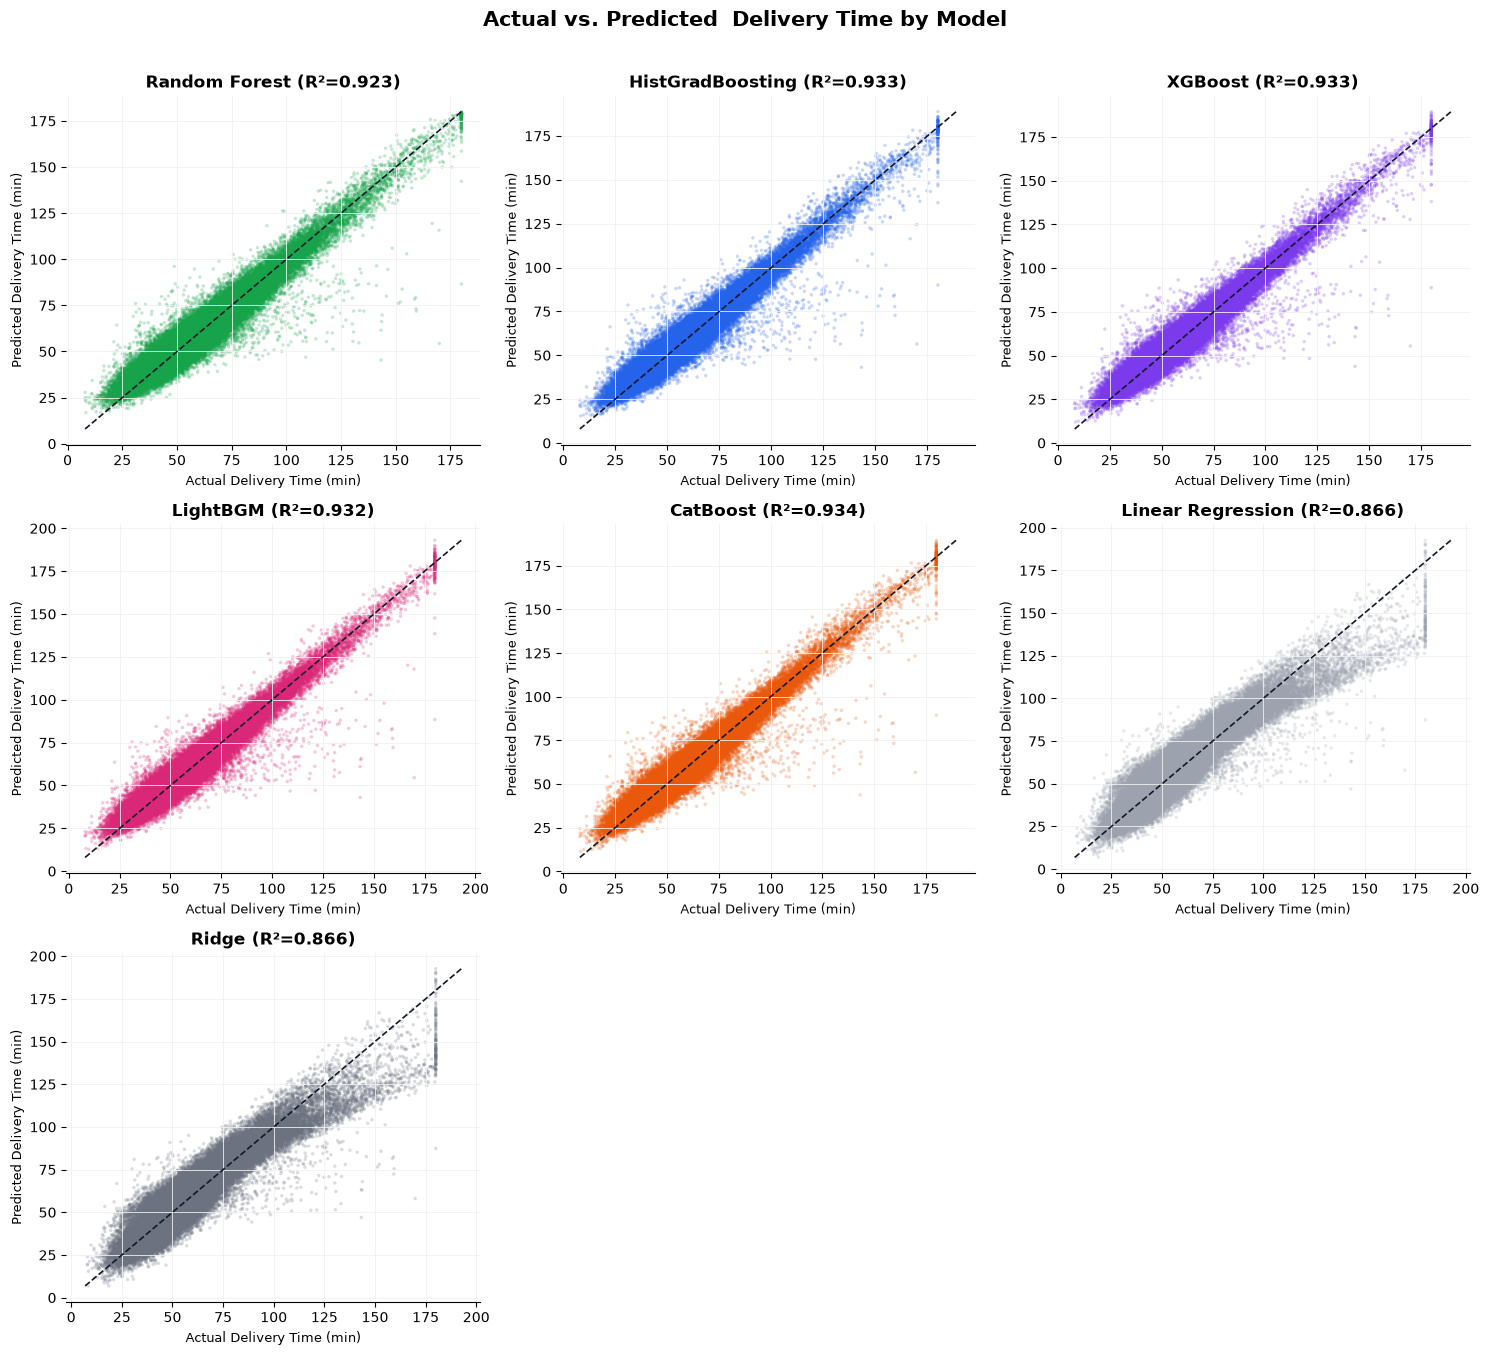

In [81]:
all_best_models = {
    "Random Forest": best_rf_model,
    "HistGradBoosting": best_hgb_model,
    "XGBoost": best_xgb_model,
    "LightBGM": best_lgbm_model,
    "CatBoost": best_catboost_model,
    "Linear Regression": lr_model,
    "Ridge": best_ridge_model
}

n_cols = 3 
n_rows = int(np.ceil(len(all_best_models) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4.5 * n_rows))
axes = axes.flatten()

for ax, (name, model) in zip(axes, all_best_models.items()):
    X_ref = X_test_cb if "CatBoost" in name else X_test
    y_pred = model.predict(X_ref)
    if "test_r2_tuned" in final_results[name]:
        r2 = final_results[name]["test_r2_tuned"]
    else:
        r2 = final_results[name]["test_r2"]
    ax.scatter(y_test, y_pred, s=6, alpha=0.25, color=model_color_codes[name], edgecolor="none")
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, color="#111827", linestyle="--", linewidth=1.2)
    ax.set_title(f"{name} (R\u00b2={r2:.3f})", fontweight="bold", fontsize=12)
    ax.set_xlabel("Actual Delivery Time (min)", fontsize=9)
    ax.set_ylabel("Predicted Delivery Time (min)", fontsize=9)
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.grid(color="#f0f0f0", linewidth=0.6)

axes[-1].axis("off")
axes[-2].axis("off")

fig.suptitle("Actual vs. Predicted  Delivery Time by Model", fontsize=15, fontweight="bold", y=1.0)
plt.tight_layout(rect=[0, 0, 1, 0.99])

plt.show()

## Feature Importance Analysis

In [82]:
from sklearn.inspection import permutation_importance

def get_importance_df(model, X_ref, y_ref, top_n=15):
    """
    Extract a sorted feature importance table form a fitted pipeline.
    """
    if hasattr(model, "named_steps"):
        estimator = model.named_steps["estimator"]
        if hasattr(estimator, "feature_importances_"):
            feature_names = model.named_steps["preprocessor"].get_feature_names_out()
            importances = estimator.feature_importances_
        else:
            # HistGradientBoostingRegressor: no feature_importances - using permutation instead
            perm = permutation_importance(model, X_ref, y_ref, n_repeats=10, random_state=42, n_jobs=-1)
            feature_names = X_ref.columns
            importances = perm.importances_mean
    else:
        # CatBoost fitted directly, not wrapped in pipeline
        estimator = model
        feature_names = estimator.feature_names_
        importances = estimator.feature_importances_
        
    df = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values("importance", ascending=False).head(top_n)

    return df

importance_tables = {}
for model_name, pipeline in all_best_models.items():
    if "HistGradBoosting" in model_name:
        importance_tables[model_name] = get_importance_df(pipeline, X_val, y_val)
    elif "Linear Regression" or "Ridge" in model_name:
        importance_tables[model_name] = get_importance_df(pipeline, X_train, y_train)    
    else:
        importance_tables[model_name] = get_importance_df(pipeline, None, None)

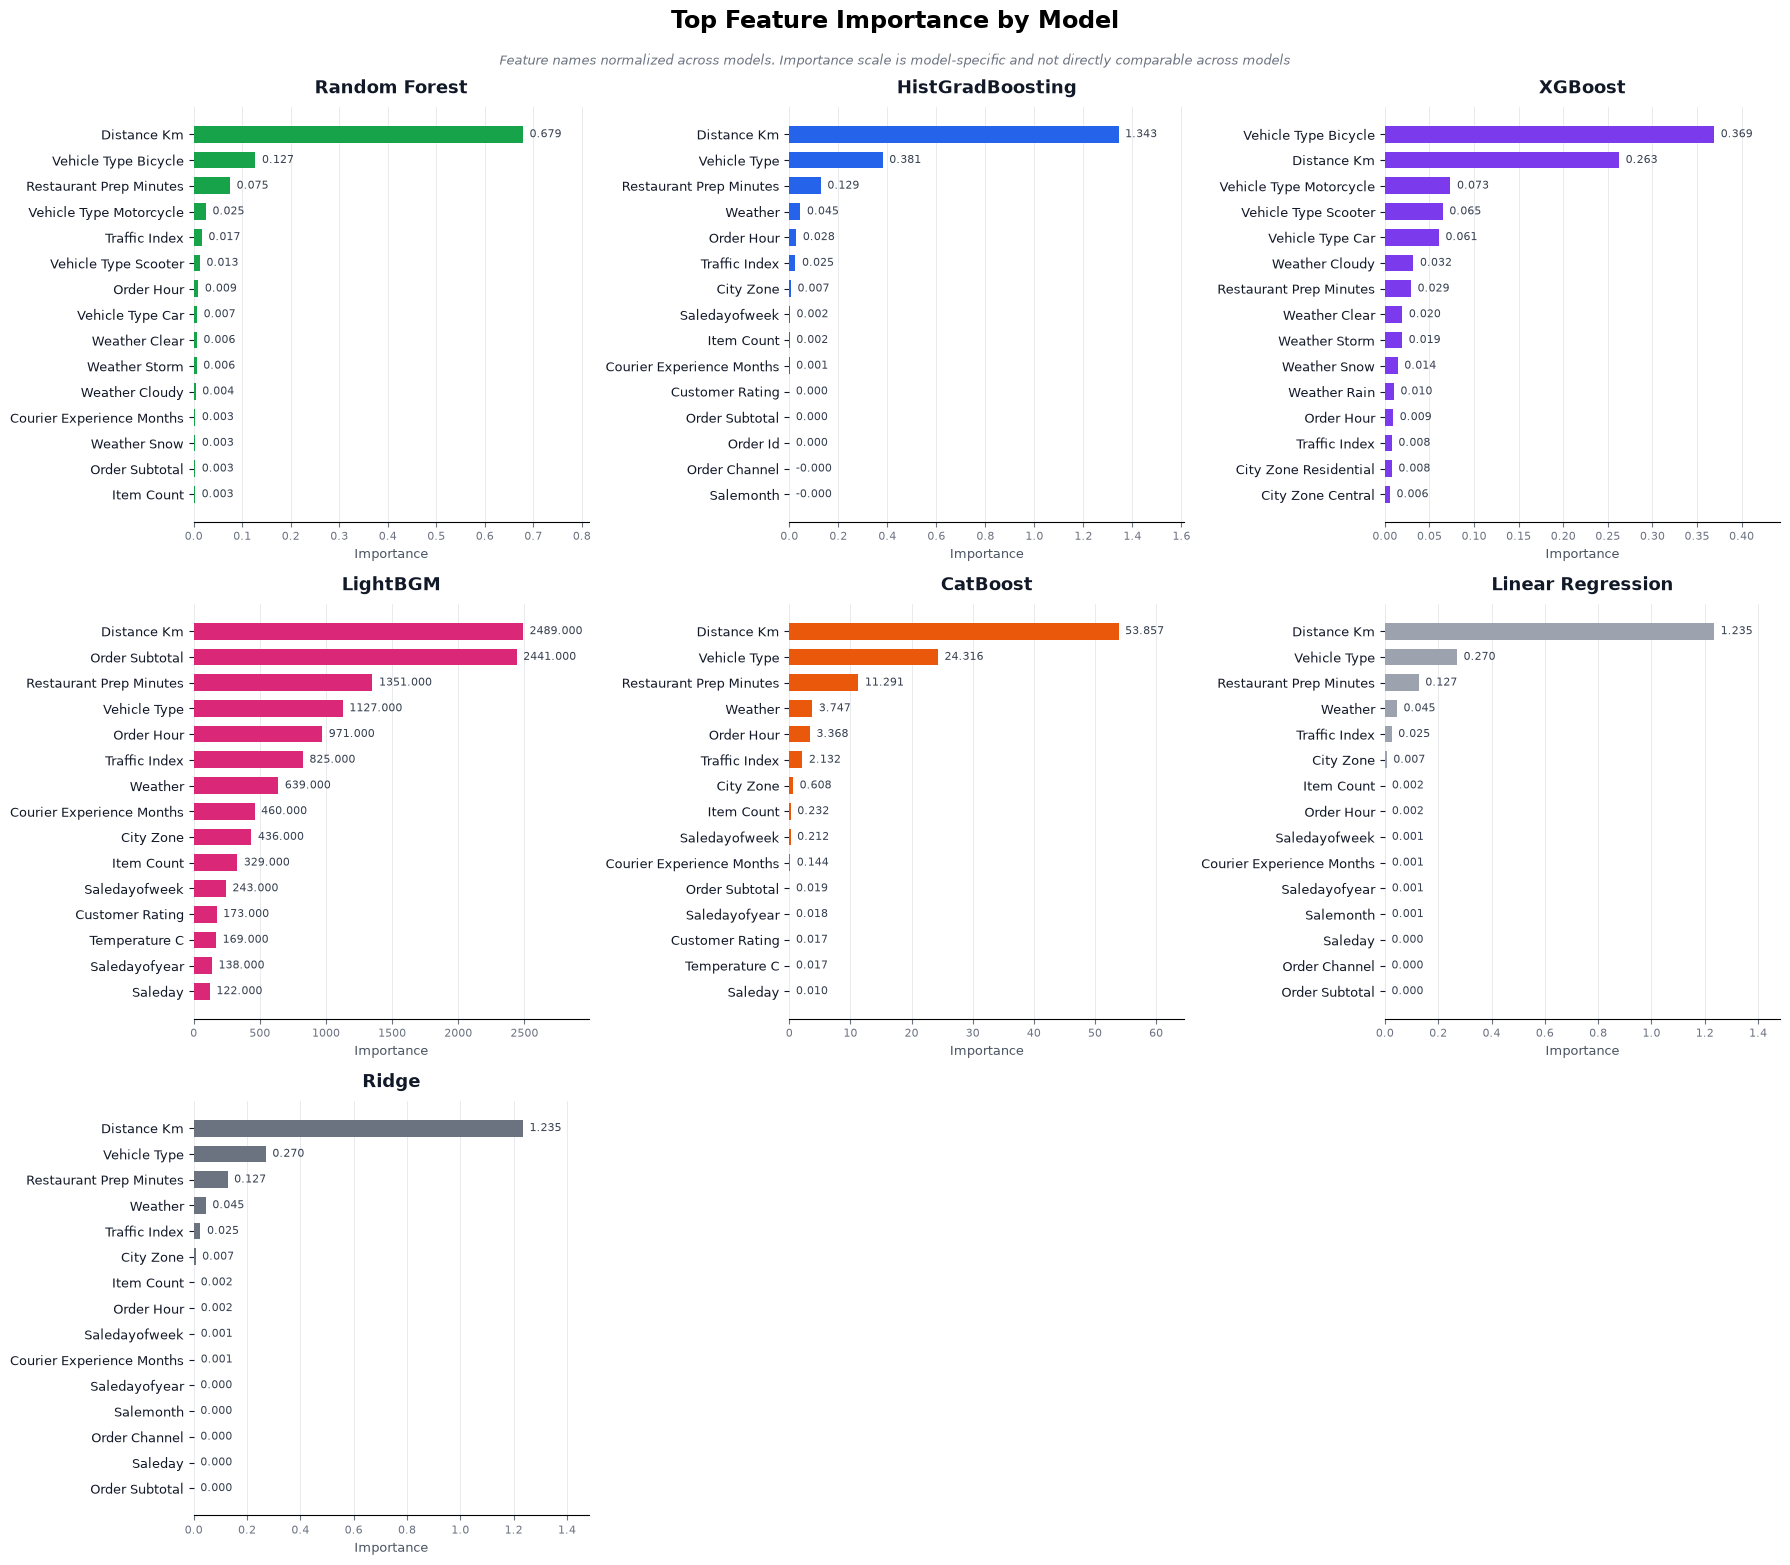

In [83]:
# Graphical representation of feature importance
import re

def clean_feature_name(name):
    name = re.sub(r"^(num__|cat__)", "", name)
    name = name.replace("_", " ")
    return name.title()

plt.rcParams["font.family"] = "DejaVu Sans"

n_models = len(importance_tables)
n_cols = 3
n_rows = int(np.ceil(n_models/ n_cols))

fig, axes =  plt.subplots(n_rows, n_cols, figsize=(18, 5.2 * n_rows))
axes = axes.flatten()

for ax, (name, df) in zip(axes, importance_tables.items()):
    df_plot = df.iloc[::-1]
    labels = [clean_feature_name(f) for f in df_plot["feature"]]
    values = df_plot["importance"].values
    color = model_color_codes[name]

    bars = ax.barh(labels, values, color=color, height=0.65, zorder=3)

    max_val = values.max()

    for bar, val in zip(bars, values):
        ax.text(val + max_val * 0.02, bar.get_y() + bar.get_height()/2, f"{val:.3f}", va="center", fontsize=8, color="#374151")

    ax.set_title(name, fontweight="bold", fontsize=13, color="#111827", pad=10)
    ax.set_xlabel("Importance", fontsize=9.5, color="#4B5563")
    ax.set_xlim(0, max_val*1.2)
    ax.tick_params(axis="y", labelsize=9.5, colors="#111827")
    ax.tick_params(axis="x", labelsize=8, colors="#6B7280")

    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.grid(axis="x", linestyle="-", linewidth=0.6, color="#E5E7EB", zorder=0)
    ax.grid(axis="y", visible=False)

# Hide unused plots
axes[-1].axis("off")
axes[-2].axis("off")

fig.suptitle("Top Feature Importance by Model", fontsize=17, fontweight="bold", y=1.0)
fig.text(0.5, 0.965, 
         "Feature names normalized across models. Importance scale is model-specific and not directly comparable across models",
        ha="center", fontsize=9.5, color="#6B7280", style="italic")

plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()


### Feature consensus across all models

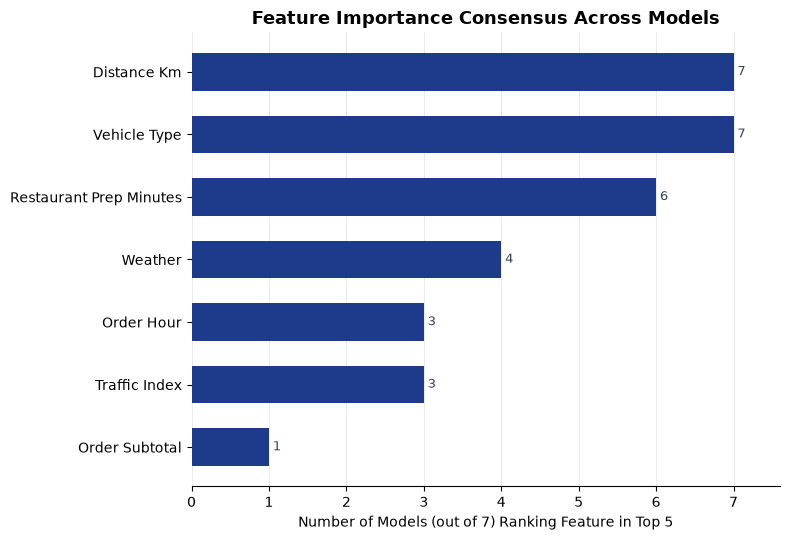

In [84]:
import re

def base_feature(raw_name, cat_features):
    """Map a possibly one-hot-encoded feature name back to its parent column,
    so Random Forest's dummy columns (e.g. vehicle_type_bike) aggregate with
    the single ordinal 'vehicle_type' column used by the other models."""
    name = re.sub(r"^(num__|cat__)", "", raw_name)
    for c in cat_features:
        if name.startswith(c + "_"):
            return c
    return name

def get_full_importance_df(pipeline):
    """Full (untruncated) importance table, aggregated by base feature."""
    estimator = pipeline.named_steps["estimator"]
    feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()
    importances = estimator.feature_importances_
    df = pd.DataFrame({"feature": feature_names, "importance": importances})
    df["base_feature"] = df["feature"].apply(lambda f: base_feature(f, cat_features))
    return df.groupby("base_feature")["importance"].sum().reset_index() \
             .sort_values("importance", ascending=False)

top5_sets = {}
for name, pipeline in all_best_models.items():
    if "HistGradBoosting" in name:
        full_df = get_importance_df(pipeline, X_val, y_val)
    elif "Linear Regression" or "Ridge" in name:
        full_df = get_importance_df(pipeline, X_train, y_train)
    else:
        full_df = get_importance_df(pipeline, None, None)
    full_df["base_feature"] = full_df["feature"].apply(lambda f: base_feature(f, cat_features))
    top5_sets[name] = set(clean_feature_name(f).title() for f in full_df["base_feature"].head(5))

counts = {}
for name, top5 in top5_sets.items():
    for f in top5:
        counts[f] = counts.get(f, 0) + 1

count_df = pd.DataFrame({"feature": list(counts.keys()), "count": list(counts.values())}) \
             .sort_values("count", ascending=True)

fig, ax = plt.subplots(figsize=(8, 5.5))
bars = ax.barh(count_df["feature"], count_df["count"], color="#1E3A8A", height=0.6, zorder=3)
for bar, val in zip(bars, count_df["count"]):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2, str(val), va="center", fontsize=9, color="#374151")
ax.set_xlim(0, len(all_best_models) + 0.6)
ax.set_xticks(range(0, len(all_best_models) + 1))
ax.set_xlabel(f"Number of Models (out of {len(all_best_models)}) Ranking Feature in Top 5")
ax.set_title("Feature Importance Consensus Across Models", fontweight="bold", fontsize=13)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.grid(axis="x", color="#E5E7EB", linewidth=0.6, zorder=0)
plt.tight_layout()
plt.show()

## Conclusions

1. `CatBoost` and `HGBoost` performed the best (R² Score), `RandomForest` averagely and linear models far below the tree based models.
2. Tuning gains, although not 0 were quite flat. No significant improvement over untuned models.
3. In case of `RandomForest`, the tuned test R² barely moved but the train R² dropped significantly, indicating that the tuned model is much less overfit and therefore more trustworthy.
4. `CatBoost` achieved a gain in R² in approximately 29 minutes whereas `HistGradBoosting` achieved a better gain in less than 2 minutes. This justifies that `HistGradBoosting` my be the best choice of model for this problem.
5. All model predictions have a tendency to compress towards the mean, i.e. the predictions for actual delivery times in extreme range (75 min or more) tend to be underestimated as shown by the scatter below the y=x dashed line in Figure 5. 